In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.style
# import matplotlib as mpl
# import seaborn as sns
%config InlineBackend.figure_format = 'svg'

# Data

### Load data

In [23]:
# dyn_heap = pd.read_csv('data/run-1/time_dynamic_stepping_path_oheap.csv')
# dyn_map = pd.read_csv('data/run-1/time_dynamic_stepping_path_omap.csv')
# dyn_queue_fill = pd.read_csv('data/run-1/time_dynamic_stepping_path_oqueue_fill.csv')
# dyn_queue_rar = pd.read_csv('data/run-1/time_dynamic_stepping_path_oqueue_rar.csv')
# dyn_ram = pd.read_csv('data/run-1/time_dynamic_stepping_path_oram.csv')
# dyn_stack = pd.read_csv('data/run-1/time_dynamic_stepping_path_ostack.csv')
# stt_heap = pd.read_csv('data/run-1/time_static_path_oheap.csv')
# stt_map = pd.read_csv('data/run-1/time_static_path_omap.csv')
# stt_queue = pd.read_csv('data/run-1/time_static_path_oqueue.csv')
# stt_ram = pd.read_csv('data/run-1/time_static_path_oram-4.csv')
# stt_stack = pd.read_csv('data/run-1/time_static_path_ostack.csv')

In [24]:
runs = {}
run_count = 4
for i in range(1, 1 + run_count):
    runs[i] = {}
    runs[i]['dyn_heap'] = pd.read_csv(f'data/run-{i}/time_dynamic_stepping_path_oheap.csv')
    runs[i]['dyn_map'] = pd.read_csv(f'data/run-{i}/time_dynamic_stepping_path_omap.csv')
    runs[i]['dyn_queue_fill'] = pd.read_csv(f'data/run-{i}/time_dynamic_stepping_path_oqueue_fill.csv')
    runs[i]['dyn_queue_rar'] = pd.read_csv(f'data/run-{i}/time_dynamic_stepping_path_oqueue_rar.csv')
    runs[i]['dyn_ram'] = pd.read_csv(f'data/run-{i}/time_dynamic_stepping_path_oram.csv')
    runs[i]['dyn_stack'] = pd.read_csv(f'data/run-{i}/time_dynamic_stepping_path_ostack.csv')
    runs[i]['stt_heap'] = pd.read_csv(f'data/run-{i}/time_static_path_oheap.csv')
    runs[i]['stt_map'] = pd.read_csv(f'data/run-{i}/time_static_path_omap.csv')
    runs[i]['stt_queue'] = pd.read_csv(f'data/run-{i}/time_static_path_oqueue.csv')
    runs[i]['stt_ram'] = pd.read_csv(f'data/run-{i}/time_static_path_oram-4.csv')
    runs[i]['stt_stack'] = pd.read_csv(f'data/run-{i}/time_static_path_ostack.csv')

files = ['dyn_heap', 'dyn_map', 'dyn_queue_fill', 'dyn_queue_rar', 'dyn_ram', 'dyn_stack',
         'stt_heap', 'stt_map', 'stt_queue', 'stt_ram', 'stt_stack']

In [25]:
data = {}
for f in files:
    for i in range(1, 1+run_count):
        if i == 1:
            data[f] = runs[1][f]
        else:
            for col in runs[1][f].columns:
                data[f][col] += runs[i][f][col]
    for col in runs[1][f].columns:
        data[f][col] /= run_count
list(data.keys())

['dyn_heap',
 'dyn_map',
 'dyn_queue_fill',
 'dyn_queue_rar',
 'dyn_ram',
 'dyn_stack',
 'stt_heap',
 'stt_map',
 'stt_queue',
 'stt_ram',
 'stt_stack']

In [26]:
# files = data.keys()
# for f in files:
#     cols = filter(lambda x: x!='n' and not x.endswith('accesses') and not x.endswith('bytes'), data[f].columns)
#     for col in cols:
#         for i in range(1, 1+run_count):
#             plt.plot(runs[i][f]['n'], runs[i][f][col], label=f'{f}-{col}-{i}')
#         plt.plot(data[f]['n'], data[f][col], label=f'{f}-{col}-avg')
# #         plt.xscale(base=2)
#         plt.legend()
#         plt.show()

In [27]:
for f in filter(lambda x: x.startswith('dyn'), data.keys()):
    for col in filter(lambda x: x.startswith('fill'), data[f].columns):
        data[f][col] = data[f][col].diff() / data[f]['n'].diff()

In [28]:
dyn_heap = data['dyn_heap']
dyn_map = data['dyn_map']
dyn_queue_fill = data['dyn_queue_fill']
dyn_queue_rar = data['dyn_queue_rar']
dyn_ram = data['dyn_ram']
dyn_stack = data['dyn_stack']
stt_heap = data['stt_heap']
stt_map = data['stt_map']
stt_queue = data['stt_queue']
stt_ram = data['stt_ram']
stt_stack = data['stt_stack']

### Clean data

In [29]:
alln = np.arange(1, (2**24)+1, dtype=np.uint64)
np2_arr = (2 ** (np.ceil(np.log2(alln)))).astype(np.uint64)

naiiver = pd.DataFrame(alln, columns=['n'])
naiiver['np2'] = np2_arr

# Fill cost: fraction of fill cost of np2
naiiver['fill_frac'] = 1 / naiiver['np2']
# naiiver['fill_frac'][naiiver['n'] == naiiver['np2']] = 1
naiiver['fill_frac'][(naiiver['n'] - 1) == (naiiver['np2'] / 2)] = 1 + (naiiver['n'] / naiiver['np2'])
naiiver['fill_frac'][naiiver['n'] == 2] = 1

# Fill cost: fraction of alloc+init cost of np2
naiiver['fill_ai_frac'] = 0
naiiver['fill_ai_frac'][(naiiver['n'] - 1) == (naiiver['np2'] / 2)] = 1
naiiver['fill_ai_frac'][naiiver['n'] == 2] = 1

/var/folders/vp/c_37y0_x1tb48ny75yll2nw40000gq/T/ipykernel_18333/3384174199.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naiiver['fill_frac'][(naiiver['n'] - 1) == (naiiver['np2'] / 2)] = 1 + (naiiver['n'] / naiiver['np2'])
/var/folders/vp/c_37y0_x1tb48ny75yll2nw40000gq/T/ipykernel_18333/3384174199.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  naiiver['fill_frac'][naiiver['n'] == 2] = 1
/var/folders/vp/c_37y0_x1tb48ny75yll2nw40000gq/T/ipykernel_18333/3384174199.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://

In [30]:
def grow_naive(df):
    df_copy = df.copy(deep=True)
    df_copy['n'] = 2 ** df['n']
    res = (pd.merge(naiiver, df_copy, left_on='np2', right_on='n', suffixes=('', '_temp'))
           .drop(columns=['n_temp', 'alloc']))
    
    res['fill'] = (res['fill'] - res['init']) * res['fill_frac']
    res['fill_accesses'] = (res['fill_accesses'] - res['init_accesses']) * res['fill_frac']
    res['fill_bytes'] = (res['fill_bytes'] - res['init_bytes']) * res['fill_frac']
    
    res['init'] *= res['fill_ai_frac']
    res['init_accesses'] *= res['fill_ai_frac']
    res['init_bytes'] *= res['fill_ai_frac']
    
    res['fill'] += res['init']
    res['fill_accesses'] += res['init_accesses']
    res['fill_bytes'] += res['init_bytes']
    
    res = res.drop(columns=['np2', 'fill_frac', 'fill_ai_frac',
                            'init', 'init_accesses', 'init_bytes'])
    
#     for col in filter(lambda x: x.startswith('fill'), res.columns):
#         res[col] = res[col].cumsum()

    return res

In [31]:
def gte8(df):
    return df[df['n']>=8]

def gte3(df):
    return df[df['n']>=3]

In [32]:
naive_heap = gte8(grow_naive(stt_heap))
naive_map = gte8(grow_naive(stt_map))
naive_queue = gte8(grow_naive(stt_queue))
naive_ram = gte8(grow_naive(stt_ram))
naive_stack = gte8(grow_naive(stt_stack))

In [33]:
stt_heap['n'] = 2 ** stt_heap['n']
stt_map['n'] = 2 ** stt_map['n']
stt_queue['n'] = 2 ** stt_queue['n']
stt_ram['n'] = 2 ** stt_ram['n']
stt_stack['n'] = 2 ** stt_stack['n']

In [34]:
dyn_heap = gte8(dyn_heap)
dyn_map = gte8(dyn_map)
dyn_queue_fill = gte8(dyn_queue_fill)
dyn_queue_rar = gte8(dyn_queue_rar)
dyn_ram = gte8(dyn_ram)
dyn_stack = gte8(dyn_stack)
stt_heap = gte8(stt_heap)
stt_map = gte8(stt_map)
stt_queue = gte8(stt_queue)
stt_ram = gte8(stt_ram)
stt_stack = gte8(stt_stack)

In [35]:
latency = 2.5e-5 # seconds
bandwidth = 10 * (1 << 27) # 10Gbps = 1.25 GBps

def networked(df, act):
    # Assuming the bandwidth doesn't become a bottleneck
    return df[act] + (latency * df[act+'_accesses']) + (df[act+'_bytes'] / bandwidth)

def networked_fill(df):
    return networked(df, 'fill')

def networked_rar(df):
    return networked(df, 'rar')

# Plots

Fill/RaR plots have networking costs incorporated into them.

## RAM

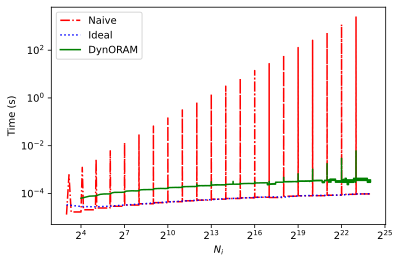

In [37]:
plt.plot(naive_ram['n'], naive_ram['fill'], label='Naive', linestyle='-.', color='red')
plt.plot(stt_ram['n'], stt_ram['fill'] / stt_ram['n'], label='Ideal', linestyle=':', color='blue')
plt.plot(dyn_ram['n'], dyn_ram['fill'], label='DynORAM', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
# plt.savefig('plots/dynamic_oram_alloc.eps')
plt.show()

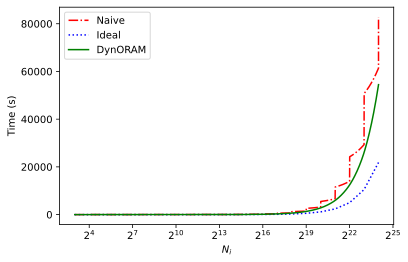

In [40]:
plt.plot(naive_ram['n'], networked_fill(naive_ram), label='Naive', linestyle='-.', color='red')
plt.plot(stt_ram['n'], networked_fill(stt_ram), label='Ideal', linestyle=':', color='blue')
plt.plot(dyn_ram['n'], networked_fill(dyn_ram) * .6666, label='DynORAM', linestyle='-', color='green')

# plt.title('Remote ORAM Fill')
plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
# plt.savefig('plots/dynamic_oram_alloc.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


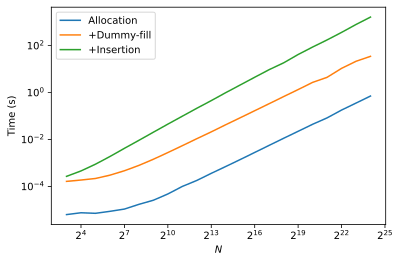

In [39]:
plt.plot(stt_ram['n'], stt_ram['alloc'], label='Allocation')
plt.plot(stt_ram['n'], stt_ram['init'], label='+Dummy-fill')
plt.plot(stt_ram['n'], stt_ram['fill'], label='+Insertion')

plt.xlabel('$N$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
plt.savefig('plots/path_oram_alloc.eps')
plt.show()

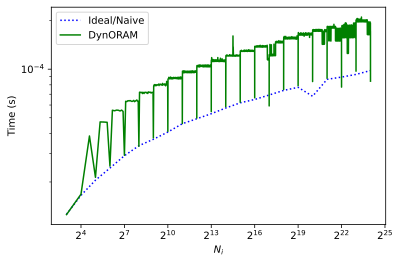

In [24]:
plt.plot(stt_ram['n'], stt_ram['rar'], label='Ideal/Naive', linestyle=':', color='blue')
plt.plot(dyn_ram['n'], dyn_ram['rar'], label='DynORAM', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
# plt.savefig('plots/dynamic_oram_read.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


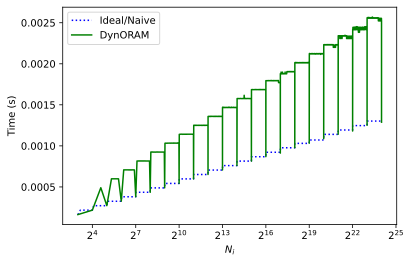

In [38]:
plt.plot(naive_ram['n'], networked_rar(naive_ram), label='Ideal/Naive', linestyle=':', color='blue')
plt.plot(dyn_ram['n'], networked_rar(dyn_ram), label='DynORAM', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
# plt.yscale('log')
plt.legend()
plt.savefig('plots/dynamic_oram_read.eps')
plt.show()

## Map

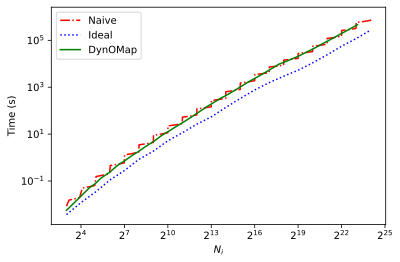

In [26]:
plt.plot(naive_map['n'], naive_map['fill'], label='Naive', linestyle='-.', color='red')
plt.plot(stt_map['n'], stt_map['fill'], label='Ideal', linestyle=':', color='blue')
plt.plot(dyn_map['n'], dyn_map['fill'], label='DynOMap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
# plt.savefig('plots/dynamic_omap_alloc.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


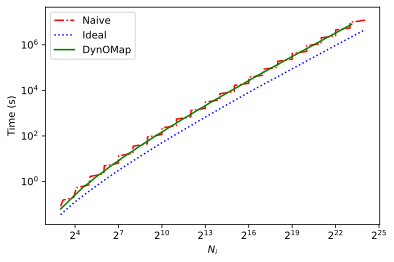

In [34]:
plt.plot(naive_map['n'], networked_fill(naive_map), label='Naive', linestyle='-.', color='red')
plt.plot(stt_map['n'], networked_fill(stt_map), label='Ideal', linestyle=':', color='blue')
plt.plot(dyn_map['n'], networked_fill(dyn_map), label='DynOMap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
plt.savefig('plots/dynamic_omap_alloc.eps')
plt.show()

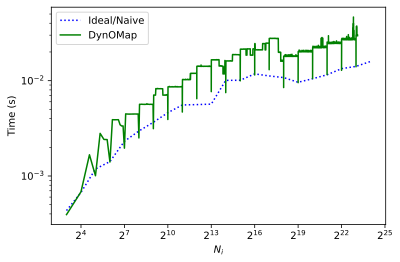

In [28]:
plt.plot(stt_map['n'], stt_map['rar'], label='Ideal/Naive', linestyle=':', color='blue')
plt.plot(dyn_map['n'], dyn_map['rar'], label='DynOMap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
# plt.savefig('plots/dynamic_omap_read.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


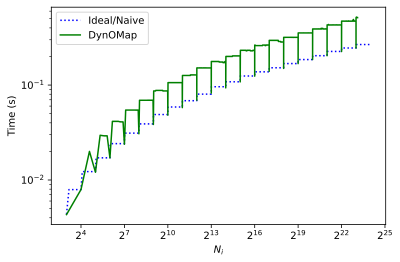

In [35]:
plt.plot(naive_map['n'], networked_rar(naive_map), label='Ideal/Naive', linestyle=':', color='blue')
plt.plot(dyn_map['n'], networked_rar(dyn_map), label='DynOMap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
plt.savefig('plots/dynamic_omap_read.eps')
plt.show()

## Stack

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


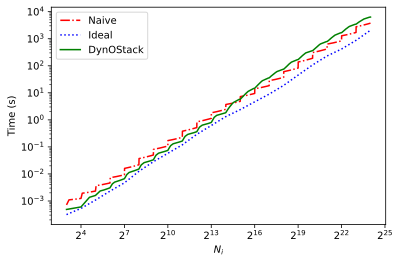

In [19]:
# plt.plot(naive_stack['n'], naive_stack['fill'], label='Naive', linestyle='-.', color='red')
# plt.plot(stt_stack['n'], stt_stack['fill'], label='Ideal', linestyle=':', color='blue')
# plt.plot(dyn_stack['n'], dyn_stack['fill'], label='DynOStack', linestyle='-', color='green')

# plt.xlabel('$N_i$')
# plt.ylabel('Time (s)')
# plt.xscale('log', base=2)
# plt.yscale('log')
# plt.legend()
# plt.savefig('plots/dynamic_ostack_alloc.eps')
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


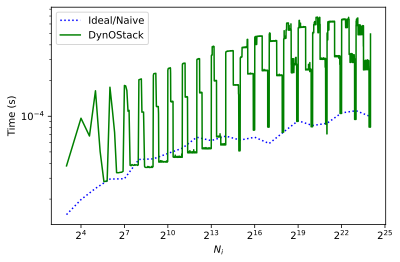

In [20]:
# plt.plot(stt_stack['n'], stt_stack['rar'], label='Ideal/Naive', linestyle=':', color='blue')
# plt.plot(dyn_stack['n'], dyn_stack['rar'], label='DynOStack', linestyle='-', color='green')

# plt.xlabel('$N_i$')
# plt.ylabel('Time (s)')
# plt.xscale('log', base=2)
# plt.yscale('log')
# plt.legend()
# plt.savefig('plots/dynamic_ostack_read.eps')
# plt.show()

## Queue

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


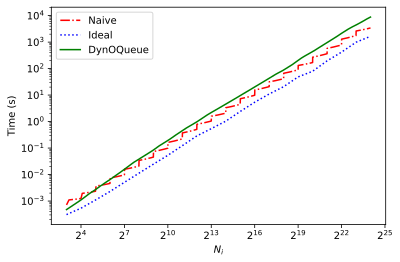

In [21]:
# plt.plot(naive_queue['n'], naive_queue['fill'], label='Naive', linestyle='-.', color='red')
# plt.plot(stt_queue['n'], stt_queue['fill'], label='Ideal', linestyle=':', color='blue')
# plt.plot(dyn_queue_fill['n'], dyn_queue_fill['fill'], label='DynOQueue', linestyle='-', color='green')

# plt.xlabel('$N_i$')
# plt.ylabel('Time (s)')
# plt.xscale('log', base=2)
# plt.yscale('log')
# plt.legend()
# plt.savefig('plots/dynamic_oqueue_alloc.eps')
# plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


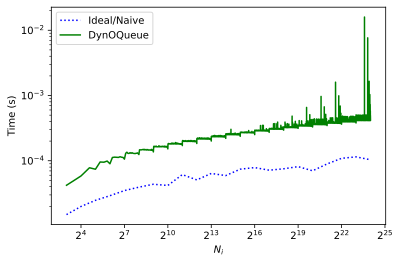

In [22]:
# plt.plot(stt_queue['n'], stt_queue['rar'], label='Ideal/Naive', linestyle=':', color='blue')
# plt.plot(dyn_queue_rar['n'], dyn_queue_rar['rar'], label='DynOQueue', linestyle='-', color='green')

# plt.xlabel('$N_i$')
# plt.ylabel('Time (s)')
# plt.xscale('log', base=2)
# plt.yscale('log')
# plt.legend()
# plt.savefig('plots/dynamic_oqueue_read.eps')
# plt.show()

## Heap

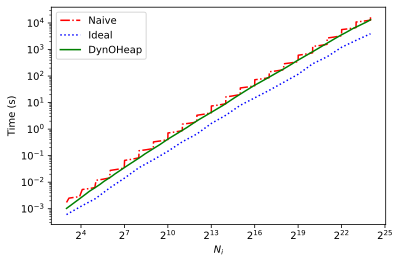

In [31]:
plt.plot(naive_heap['n'], naive_heap['fill'], label='Naive', linestyle='-.', color='red')
plt.plot(stt_heap['n'], stt_heap['fill'], label='Ideal', linestyle=':', color='blue')
plt.plot(dyn_heap['n'], dyn_heap['fill'], label='DynOHeap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
# plt.savefig('plots/dynamic_oheap_alloc.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


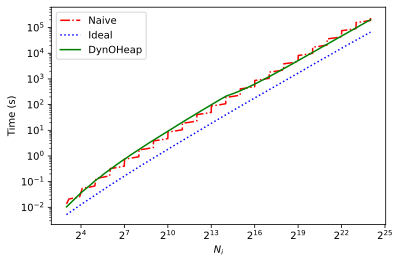

In [30]:
plt.plot(naive_heap['n'], networked_fill(naive_heap), label='Naive', linestyle='-.', color='red')
plt.plot(stt_heap['n'], networked_fill(stt_heap), label='Ideal', linestyle=':', color='blue')
plt.plot(dyn_heap['n'], networked_fill(dyn_heap), label='DynOHeap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
plt.savefig('plots/dynamic_oheap_alloc.eps')
plt.show()

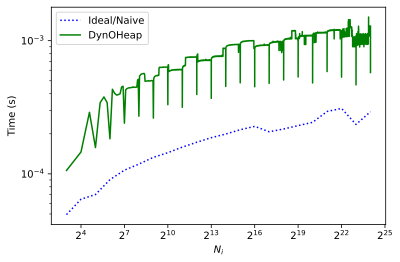

In [32]:
plt.plot(stt_heap['n'], stt_heap['rar'], label='Ideal/Naive', linestyle=':', color='blue')
plt.plot(dyn_heap['n'], dyn_heap['rar'], label='DynOHeap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()

# plt.savefig('plots/dynamic_oheap_read.eps')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


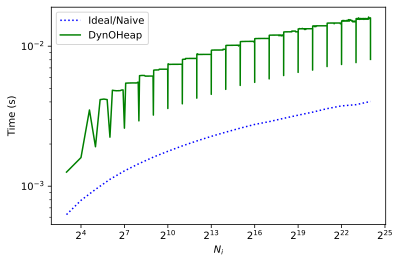

In [33]:
plt.plot(stt_heap['n'], networked_rar(stt_heap), label='Ideal/Naive', linestyle=':', color='blue')
plt.plot(dyn_heap['n'], networked_rar(dyn_heap), label='DynOHeap', linestyle='-', color='green')

plt.xlabel('$N_i$')
plt.ylabel('Time (s)')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()

plt.savefig('plots/dynamic_oheap_read.eps')
plt.show()

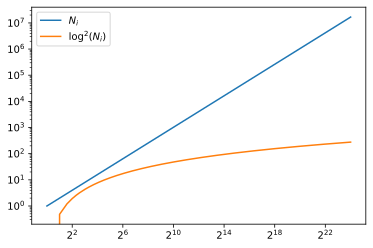

In [44]:
ns = np.arange(1, (2**24)+1, dtype=np.uint64)
log2ns = np.log(ns) ** 2
plt.plot(ns, ns, label='$N_i$')
plt.plot(ns, log2ns, label='$\log^2(N_i)$')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
plt.show()